# 🎮 Phase 5: Reinforcement Learning (Q-Learning)
**Algorithm:** Q-Learning with ε-greedy exploration  
---

## 1️⃣ Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

ACTIONS = {0: 'Dynamic Pricing', 1: 'Personalized Offer',
           2: 'Loyalty Reward', 3: 'Re-engagement Campaign', 4: 'Churn Prevention'}
print('✅ Ready!')

✅ Ready!


## 2️⃣ Load Cluster Labels

In [2]:
cluster_labels = np.load('../outputs/reports/cluster_labels_train.npy')
y_train = np.load('../outputs/reports/y_train.npy')
print(f'✅ Customers: {len(cluster_labels)}')
print(f'✅ Segments: {np.unique(cluster_labels)}')

✅ Customers: 16675
✅ Segments: [0 1 2]


## 3️⃣ Q-Learning Agent & Environment

In [3]:
class QLearningAgent:
    def __init__(self, n_states, n_actions, lr=0.1, gamma=0.95, epsilon=1.0):
        self.q_table = np.zeros((n_states, n_actions))
        self.lr, self.gamma = lr, gamma
        self.epsilon, self.epsilon_min = epsilon, 0.01
        self.epsilon_decay = 0.995

    def choose_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.q_table.shape[1])
        return np.argmax(self.q_table[state])

    def learn(self, state, action, reward, next_state):
        current_q = self.q_table[state, action]
        self.q_table[state, action] += self.lr * (
            reward + self.gamma * np.max(self.q_table[next_state]) - current_q)

    def decay(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

print('✅ Agent defined!')

✅ Agent defined!


## 4️⃣ Train Q-Learning

In [4]:
n_states = len(np.unique(cluster_labels))
agent = QLearningAgent(n_states, len(ACTIONS))
episode_rewards, epsilon_hist = [], []

for episode in range(1000):
    idx = np.random.randint(len(cluster_labels))
    state = int(cluster_labels[idx])
    total_reward = 0
    for _ in range(10):
        action = agent.choose_action(state)
        purchase_prob = y_train[idx]
        reward = purchase_prob * 10
        if state == 0 and action == 3: reward += 3
        elif state == 1 and action == 2: reward += 3
        next_idx = np.random.randint(len(cluster_labels))
        next_state = int(cluster_labels[next_idx])
        agent.learn(state, action, reward, next_state)
        total_reward += reward
        state, idx = next_state, next_idx
    agent.decay()
    episode_rewards.append(total_reward)
    epsilon_hist.append(agent.epsilon)
    if (episode+1) % 200 == 0:
        print(f'Episode {episode+1} | Avg Reward: {np.mean(episode_rewards[-100:]):.2f} | ε: {agent.epsilon:.3f}')

np.save('../outputs/reports/q_table.npy', agent.q_table)
print('✅ Q-Learning Training Complete!')

Episode 200 | Avg Reward: 63.40 | ε: 0.367
Episode 400 | Avg Reward: 68.70 | ε: 0.135
Episode 600 | Avg Reward: 71.81 | ε: 0.049
Episode 800 | Avg Reward: 64.46 | ε: 0.018
Episode 1000 | Avg Reward: 73.64 | ε: 0.010
✅ Q-Learning Training Complete!


## 5️⃣ Training Progress & Q-Table

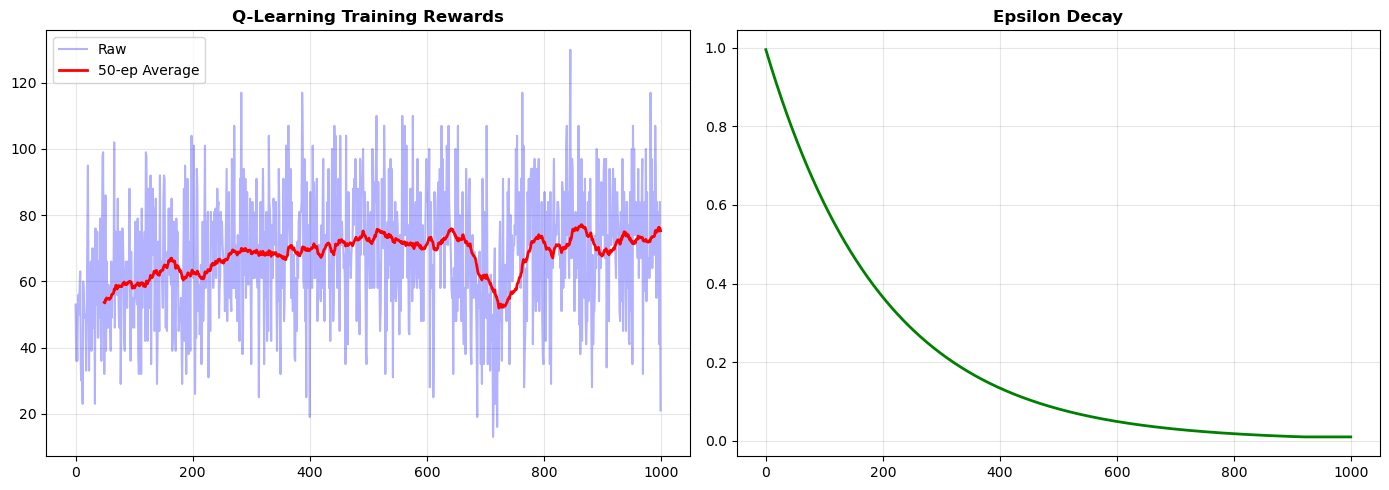


📊 Marketing Recommendations:
Cold 🔴 → Best Action: Re-engagement Campaign (Q=146.61)
VIP 🟢 → Best Action: Loyalty Reward (Q=139.90)
VIP 🟢 → Best Action: Re-engagement Campaign (Q=136.19)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
smoothed = pd.Series(episode_rewards).rolling(50).mean()
axes[0].plot(episode_rewards, alpha=0.3, color='blue', label='Raw')
axes[0].plot(smoothed, color='red', linewidth=2, label='50-ep Average')
axes[0].set_title('Q-Learning Training Rewards', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(epsilon_hist, color='green', linewidth=2)
axes[1].set_title('Epsilon Decay', fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/rl_training_progress.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n📊 Marketing Recommendations:')
for state in range(n_states):
    best = np.argmax(agent.q_table[state])
    seg = 'Cold 🔴' if state == 0 else 'VIP 🟢'
    print(f'{seg} → Best Action: {ACTIONS[best]} (Q={agent.q_table[state,best]:.2f})')